# Set Up

In [1]:
# import python and pytorch libraries
from __future__ import absolute_import
from __future__ import print_function

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import codecs
from copy import deepcopy
import os
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
import sys
import logging
import tempfile
import shutil
import pickle
import platform
import json
from datetime import datetime
import random
from sklearn import metrics
import matplotlib.pyplot as plt
import itertools
import collections
from collections import defaultdict
import shap

In [3]:
import import_ipynb
from mimic_utils_text import InHospitalMortalityReader, Discretizer, Normalizer, read_chunk

importing Jupyter notebook from mimic_utils_text.ipynb


Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.


In [4]:
LOGGER = logging.getLogger("LSTM")

LOGGER.setLevel(logging.INFO)
logging_format = logging.Formatter(
    "[%(asctime)s - %(filename)s:%(lineno)s - %(funcName)s() - %(levelname)s %(message)s"
)
ch = logging.StreamHandler()
ch.setFormatter(logging_format)
LOGGER.addHandler(ch)

In [5]:
date_today = datetime.today().strftime("%Y-%m-%d")

# Directory where the preprocessed data is saved
data_dir = "data/AKI/fts_extract_race_groups"

model_save_dir = f"data/models/{date_today}/{Path(data_dir).name}"
results_save_dir = f"data/results/{date_today}/{Path(data_dir).name}"
figure_dict = {"plotly": {}, "matplotlib": {}}
metrics_dict = {}
padding_num_features = 35  # 34 for default dataset

In [6]:
def list_to_str(l: list) -> list:
    new_list = []
    for item in l:
        if isinstance(item, list):
            new_list.append(list_to_str(item))
        elif isinstance(item, dict):
            new_list.append(dict_to_str(item))
        elif isinstance(item, np.generic):
            new_list.append(item.item())
    return new_list


def dict_to_str(d: dict) -> dict:
    for k, v in d.items():
        if isinstance(v, dict):
            dict_to_str(v)
        elif isinstance(v, list):
            d[k] = list_to_str(v)

        elif isinstance(v, np.generic):
            d[k] = v.item()
    return d

# Pytorch Dataset

In [7]:
# pad missing values in the nested lists with 0s
def pad_missing_value_with_zero(data):
    a1 = np.zeros((len(data), max([len(k) for k in data]), padding_num_features))  # 35
    for ctr, k in enumerate(data):
        # print(ctr, len(k), k)
        # Convert string representations of Boolean values to numerical values
        k = np.array([[1.0 if val == "True" else 0.0 if val == "False" else float(val) for val in row] for row in k])

        a1[ctr, : len(k), :] = k
    return a1

In [8]:
# pytroch class for reading data into batches
class MIMICDataset(Dataset):
    """
    Loads time series data into memory from a text file,
    split by newlines.
    """

    def __init__(self, reader, target_repl=False, batch_labels=False):
        self.data = []
        self.y = []
        N = reader.get_number_of_examples()
        print(f"Number of examples:{N}")
        # read data form cvs files
        ret = read_chunk(reader, N)
        # read into memory structured data X and labels y
        # print(ret)

        data = ret["X"]
        ts = ret["t"]
        labels = ret["y"]
        names = ret["name"]
        self.features = ret["header"]

        # print(data)

        # pad missing values in the list of arrays with 0s
        data = pad_missing_value_with_zero(data)

        self.data = np.array(data, dtype=np.float32)
        self.T = self.data.shape[1]

        if batch_labels:
            self.y = np.array([[l] for l in labels], dtype=np.float32)
        else:
            self.y = np.array(labels, dtype=np.float32)
        if target_repl:
            self.y = self._extend_labels(self.y)

    def _extend_labels(self, labels):
        # (B,)
        labels = labels.repeat(self.T, axis=1)  # (B, T)
        return labels

    def __len__(self):
        # overide len to get number of instances
        return len(self.data)

    def __getitem__(self, idx):
        # get features (physiological variables x) and label for a given instance index
        return self.data[idx], self.y[idx]

# Evaluation metrics
The main measure used are accuracy, ROC AUC and PR AUC.

In [9]:
# eval metrics
def print_metrics_binary(y_true, predictions, logger, verbose=1):
    predictions = np.array(predictions)
    if len(predictions.shape) == 1:
        predictions = np.stack([1 - predictions, predictions]).transpose((1, 0))
    cf = metrics.confusion_matrix(y_true, predictions.argmax(axis=1))
    if verbose:
        logger.info("confusion matrix:")
        logger.info(cf)
    cf = cf.astype(np.float32)

    acc = (cf[0][0] + cf[1][1]) / np.sum(cf)
    prec0 = cf[0][0] / (cf[0][0] + cf[1][0])
    prec1 = cf[1][1] / (cf[1][1] + cf[0][1])
    rec0 = cf[0][0] / (cf[0][0] + cf[0][1])
    rec1 = cf[1][1] / (cf[1][1] + cf[1][0])
    auroc = metrics.roc_auc_score(y_true, predictions[:, 1])

    (precisions, recalls, thresholds) = metrics.precision_recall_curve(y_true, predictions[:, 1])
    auprc = metrics.auc(recalls, precisions)
    minpse = np.max([min(x, y) for (x, y) in zip(precisions, recalls)])

    if verbose:
        logger.info("accuracy = {0:.3f}".format(acc))
        logger.info("precision class 0 = {0:.3f}".format(prec0))
        logger.info("precision class 1 = {0:.3f}".format(prec1))
        logger.info("recall class 0 = {0:.3f}".format(rec0))
        logger.info("recall class 1 = {0:.3f}".format(rec1))
        logger.info("AUC of ROC = {0:.3f}".format(auroc))
        logger.info("AUC of PRC = {0:.3f}".format(auprc))

    return {"acc": acc, "prec0": prec0, "prec1": prec1, "rec0": rec0, "rec1": rec1, "auroc": auroc, "auprc": auprc}

In [10]:
def performance_with_cutoff(y_test, pred_probabilities, verbose=1):
    # performance
    fpr, tpr, thresholds = metrics.roc_curve(y_test, pred_probabilities)
    # compute roc auc
    roc_auc = metrics.roc_auc_score(y_test, pred_probabilities, average="micro")
    # compute Precision_Recall curves
    precision, recall, _ = metrics.precision_recall_curve(y_test, pred_probabilities)
    # compute PR_AUC
    pr_auc = metrics.auc(recall, precision)

    # compute confusion matrix
    optimal_cut_off = round(thresholds[np.argmax(tpr - fpr)], 4)
    a = np.where(pred_probabilities > optimal_cut_off, 1, 0)
    brier = round(metrics.brier_score_loss(y_test, pred_probabilities, sample_weight=None, pos_label=None), 3)
    predictions = np.where(pred_probabilities > optimal_cut_off, 1, 0)
    matrix = metrics.confusion_matrix(y_test, a, labels=None, normalize=None)

    if verbose:
        LOGGER.info("confusion matrix after tuning with cutoff")
        LOGGER.info("Cut off: " + str(optimal_cut_off))
        LOGGER.info(matrix)
        LOGGER.info("accuracy with cutoff = {0:.3f}".format(metrics.accuracy_score(y_test, predictions)))

# Training
Here we define the model, loss and training loop. The model is an LSTM. 

In [11]:
# model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        tag_size,
        hidden_size,
        feat_size,
        emb_size,
        bidirectional=False,
        dropout=0.2,
        aggregation_type="last_state",
    ):
        """
        constructor, here we define the hidden layers for our architecture
        """
        super().__init__()

        # define if the rnn will be bidirectional
        self.bidirectional = bidirectional

        # define the aggregation type of the features for the classifier for example, you can take the mean
        self.aggregation_type = aggregation_type
        self.encoder = nn.Linear(feat_size, emb_size, bias=True)
        
        # Create a (bidirectional) LSTM to encode sequence
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True, bidirectional=bidirectional)

        # The output of the LSTM doubles if we use a bidirectional encoder.
        encoding_size = hidden_size * 2 if bidirectional else hidden_size
        self.combination_layer = nn.Linear(encoding_size, encoding_size)

        # Create affine layer to project to the classes
        self.projection = nn.Linear(encoding_size, tag_size)
        
        # dropout layer for regularizetion of a sequence
        self.dropout_layer = nn.Dropout(p=dropout)
        self.relu = nn.ReLU()

    def forward(self, x, seq_mask=None, seq_len=None):
        # input size
        # [B, T, feat_size] batch, time and features
        # return unormalized probabilities (logits)
        # the loss will compute the sigmoid and negative log-likelihood
        # output size
        # [B, num_class] batch, and 1 class

        # [B, T, F] batch, time, features
        h1 = self.encoder(x)
        h1 = self.relu(h1)
        # [B, T, H] batch, time, hidden or hidden * 2
        outputs, (final, _) = self.lstm(h1)

        if self.aggregation_type == "mean":
            # mean over hidden states of LSTM
            outputs = self.dropout_layer(outputs)
            h = self.relu(self.combination_layer(outputs))
            # [B, H] batch, hidden
            h = h.mean(dim=1)  # mean over time dimension
        elif self.aggregation_type == "last_state":
            # last hidden state of the lstm or concat of bidirectional forward and backward states
            if self.bidirectional:
                h_T_fwd = final[0]  # lstm 1, last hidden state of forward lstm
                h_T_bwd = final[1]  # lstm 2. last hidden state of backward lstm
                # [B, H*2]
                h = torch.cat(
                    [h_T_fwd, h_T_bwd], dim=-1
                )  # concatenate the forward with the backward in the last dimension (feat)
            else:
                h = final[-1]
            h = self.relu(self.combination_layer(h))
            h = self.dropout_layer(h)
        # [B, H] # summary for each patient
        # [B, 1]
        logits = self.projection(h)

        return logits

In [12]:
# eval model
def eval_model(model, dataset, device):
    model.eval()
    sigmoid = nn.Sigmoid()
    with torch.no_grad():
        y_true = []
        predictions = []
        for data, labels in dataset:
            data = data.to(device)
            labels = labels.to(device)
            logits = model(data)
            probs = sigmoid(logits)
            predictions += [p.item() for p in probs]  # concatenate all predictions
            y_true += [y.item() for y in labels]  # concatenate all labels
    results = print_metrics_binary(y_true, predictions, LOGGER)
    performance_with_cutoff(y_true, predictions)

    return results, predictions, y_true

In [13]:
def generate_arg_summary(args):
    arg_detail = (
        "_dropout_"
        + str(args["dropout"])
        + ",batch_size_"
        + str(args["batch_size"])
        + ",lr_"
        + str(args["lr"])
        + ",epochs_"
        + str(args["epochs"])
    )
    return arg_detail

In [14]:
def train(args):
    mode = "train"
    hidden_size = args["dim"]
    dropout = args["dropout"]
    batch_size = args["batch_size"]
    learning_rate = args["lr"]
    num_epochs = args["epochs"]
    emb_size = args["emb_size"]
    aggregation_type = args["aggregation_type"]
    bidirectional_encoder = args["bidirectional"]
    seed = args["seed"]
    steps = args["steps"]
    data = args["data"]
    notes = args["notes"]
    timestep = args["timestep"]
    normalizer_state = args["normalizer_state"]

    if seed:
        torch.manual_seed(seed)
        np.random.seed(seed)
    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    LOGGER.info(f"Device: {device}")

    # define cvs data readers

    # if(notes != None):
    train_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "train"),
        notes_dir=notes,
        listfile=os.path.join(notes, "train_listfile.csv"),
        period_length=48.0,
    )

    val_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "train"),
        notes_dir=notes,
        listfile=os.path.join(notes, "val_listfile.csv"),
        period_length=48.0,
    )
    # else:
    #     train_reader = InHospitalMortalityReader(dataset_dir=os.path.join(data, 'train'),
    #                                          notes_dir=None,
    #                                          listfile=os.path.join(notes, 'train_listfile.csv'),
    #                                          period_length=48.0)

    #     val_reader = InHospitalMortalityReader(dataset_dir=os.path.join(data, 'train'),
    #                                         notes_dir=None,
    #                                         listfile=os.path.join(notes, 'val_listfile.csv'),
    #                                         period_length=48.0)

    train_dataset = MIMICDataset(train_reader, batch_labels=True)
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = MIMICDataset(val_reader, batch_labels=True)
    val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # [B, T, feat_size] batch, time, and num of variables
    feat_size = train_dataset.data.shape[-1]

    # Define the classification model
    model = LSTMClassifier(
        tag_size=1,  # binary
        feat_size=feat_size,
        hidden_size=hidden_size,
        emb_size=emb_size,
        bidirectional=bidirectional_encoder,
        dropout=dropout,
        aggregation_type=aggregation_type,
    )

    model = model.to(device)
    LOGGER.info(args)
    LOGGER.info(model)

    # Define optimizer
    optimizer = Adam(model.parameters(), lr=learning_rate)

    # define loss for binary classification
    criterion = nn.BCEWithLogitsLoss()

    # path to save model with extension .pt on disk
    args_detail = (
        "_dropout_"
        + str(args["dropout"])
        + ",batch_size_"
        + str(args["batch_size"])
        + ",lr_"
        + str(args["lr"])
        + ",epochs_"
        + str(args["epochs"])
    )
    best_val_auc = 0.0

    results = []

    step = 0
    num_batches = 0
    e_losses = []

    for epoch in range(num_epochs):
        loss_batch2 = 0.0
        model.train()
        for x, labels in train_dl:
            x = x.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            y_logits = model(x)
            loss = criterion(y_logits, labels)
            loss_batch2 += loss.item()  # keep track of loss
            loss.backward()
            optimizer.step()
            step += 1
            num_batches += 1

            # Every number of steps show the model loss
            if step % steps == 0:
                LOGGER.info("epoch (%d) step %d: training loss = %.2f" % (epoch, step, loss_batch2 / num_batches))
                e_losses.append(loss_batch2 / num_batches)

        metrics_results, _, _ = eval_model(model, val_dl, device)
        metrics_results["epoch"] = epoch
        # save results of current epoch
        results.append(metrics_results)

        LOGGER.info(metrics_results)

        # Model selection
        if metrics_results["auroc"] > best_val_auc:
            best_val_auc = metrics_results["auroc"]
            model_save_name2 = (Path(model_save_dir) / args_detail).with_suffix(".pth")
            model_save_name2.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), str(model_save_name2))

    model_save_name1 = (Path(model_save_dir) / args_detail).with_suffix(".pth")
    model_save_name1.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), str(model_save_name1))

    plt.plot(e_losses)
    return results

In [15]:
# for plot name
# args_detail = args_detail(args)

## Training parameters

In [16]:
# execute training
# define hyperparameters
args = {
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 50,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "seed": 42,
    "steps": 1000,  # print loss every num of steps
    "data": data_dir,  # path to MIMIC data
    "notes": data_dir,  # text not used in this model
    "timestep": 1.0,  # observations every hour
    "imputation": "previous",  # imputation method
    "normalizer_state": None,
}  # we use normalization config

[2025-03-01 13:20:12,386 - 585167952.py:22 - train() - INFO Device: cuda:0


InHospitalMortalityReader init completed
InHospitalMortalityReader init completed
Number of examples:51996
Reading chunk of size 51996
Number of records with more than 48 hours: 434
Number of examples:7018
Reading chunk of size 7018
Number of records with more than 48 hours: 52


[2025-03-01 13:40:32,470 - 585167952.py:71 - train() - INFO {'dim': 35, 'dropout': 0.2, 'batch_size': 64, 'lr': 0.001, 'epochs': 50, 'emb_size': 35, 'aggregation_type': 'mean', 'bidirectional': False, 'seed': 42, 'steps': 1000, 'data': 'data/AKI/fts_extract_race_groups', 'notes': 'data/AKI/fts_extract_race_groups', 'timestep': 1.0, 'imputation': 'previous', 'normalizer_state': None}
[2025-03-01 13:40:32,470 - 585167952.py:72 - train() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)
[2025-03-01 13:40:43,864 - 1116186297.py:8 - print_metrics_binary() - INFO confusion matrix:
[2025-03-01 13:40:43,864 - 1116186297.py:9 - print_metrics_binary() - INFO [[ 590 1597]
 [ 218 4613]]
[2025-03-01 13:40:43,885 - 111

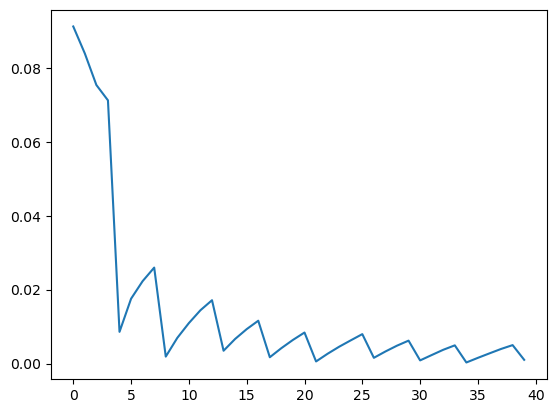

In [17]:
training_metrics = train(args)
metrics_dict["train"] = training_metrics

In [42]:
metrics_dict["train"][0]

{'acc': 0.7413793,
 'prec0': 0.730198,
 'prec1': 0.74283415,
 'rec0': 0.26977596,
 'rec1': 0.95487475,
 'auroc': 0.8112792164837724,
 'auprc': 0.9049040850455186,
 'epoch': 0}

# Manual training

To explore in detail each step in the training process

In [16]:
# Manual Training
arg_mode = "train"
arg_hidden_size = args["dim"]
arg_dropout = args["dropout"]
arg_batch_size = args["batch_size"]
arg_learning_rate = args["lr"]
arg_num_epochs = args["epochs"]
arg_emb_size = args["emb_size"]
arg_aggregation_type = args["aggregation_type"]
arg_bidirectional_encoder = args["bidirectional"]
arg_seed = args["seed"]
arg_steps = args["steps"]
arg_data = args["data"]
arg_notes = args["notes"]
arg_timestep = args["timestep"]
arg_normalizer_state = args["normalizer_state"]

if arg_seed:
    torch.manual_seed(arg_seed)
    np.random.seed(arg_seed)
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
LOGGER.info(f"Device: {device}")

# define cvs data readers

# if(notes != None):
train_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(arg_data, "train"),
    notes_dir=arg_notes,
    listfile=os.path.join(arg_notes, "train_listfile.csv"),
    period_length=48.0,
)

val_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(arg_data, "train"),
    notes_dir=arg_notes,
    listfile=os.path.join(arg_notes, "val_listfile.csv"),
    period_length=48.0,
)

[2024-12-14 22:59:58,517 - 59702241.py:22 - <module>() - INFO Device: cuda:0


InHospitalMortalityReader init completed
InHospitalMortalityReader init completed


In [ ]:
# Instead of creating and obj MIMICDataset as follow
# train_dataset = MIMICDataset(train_reader, batch_labels=True)

# We'll run each step manually to understand the process
dataset_data = []
dataset_y = []
N = train_reader.get_number_of_examples()
print(f"Number of examples:{N}")

# read data form cvs files
ret = read_chunk(train_reader, N)

# read into memory structured data X and labels y
# print(ret)

data = ret["X"]
ts = ret["t"]
labels = ret["y"]
names = ret["name"]

In [ ]:
# Check the data
len(data[0][0])

In [ ]:
def convert_datetime_columns(data, datetime_columns):
    for col in datetime_columns:
        data[:, col] = pd.to_datetime(data[:, col], errors="coerce").astype(np.int64) // 10**9
    return data


def pad_missing_value_with_zero_modified(data):
    # Assuming data is a NumPy array
    data = np.where(data == "", "0", data)  # Replace empty strings with '0'
    data = np.where(data == "?", "0", data)  # Replace '?' with '0'

In [ ]:
# datetime_columns = [11, 16, 17, 28]

# data_copy = data

# # Process each item in the list
# for i in range(len(data_copy)):
#     # Convert datetime columns to Unix timestamps
#     data_copy[i] = convert_datetime_columns(data_copy[i], datetime_columns)
#     # Pad missing values with zero
#     data_copy[i] = pad_missing_value_with_zero(data_copy[i])

In [ ]:
# pad missing values in the list of arrays with 0s
# data = pad_missing_value_with_zero(data)
# pad_a1 = np.zeros((len(data), max([len(k) for k in data]), 72))  # 35
# print(pad_a1.shape)

In [ ]:
# for ctr, k in enumerate(data):
#     # print(ctr, len(k), k)
#     # Filter out non-numeric values
#     k = [item for item in k if isinstance(item, (int, float))]
#     if len(k) > 0:
#         print("continue")
#         pad_a1[ctr, : len(k), :] = np.array(k).reshape(-1, 72)

In [ ]:
# pad_a1[0][0]

In [ ]:
# dataset_data = np.array(data, dtype=np.float32)
# dataset_T = dataset_data.shape[1]

# if batch_labels:
#     dataset_y = np.array([[l] for l in labels], dtype=np.float32)
# else:
#     dataset_y = np.array(labels, dtype=np.float32)
# if target_repl:
#     dataset_y = dataset__extend_labels(dataset_y)

In [21]:
# for plot name
args_detail = generate_arg_summary(args)

# Test
Use the last trained model or the best validation model and run in test.
Also use calibration curves.

In [32]:
def test(args):
    # define trainning and validation datasets
    mode = "test"
    hidden_size = args["dim"]
    dropout = args["dropout"]
    batch_size = args["batch_size"]
    emb_size = args["emb_size"]
    best_model = args["best_model"]
    data = args["data"]
    notes = args["notes"]
    timestep = args["timestep"]
    aggregation_type = args["aggregation_type"]
    bidirectional_encoder = args["bidirectional"]
    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    # 1. Get a unique working directory

    test_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "test"),
        notes_dir=notes,
        listfile=os.path.join(notes, "test_listfile.csv"),
        period_length=48.0,
    )

    # Read data
    test_dataset = MIMICDataset(test_reader, batch_labels=True)
    test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    # [B, M, feat_size]
    feat_size = test_dataset.data.shape[-1]
    print("FEAT_size:", feat_size)

    # Define the classification model.
    model = LSTMClassifier(
        tag_size=1,  # binary
        feat_size=feat_size,
        hidden_size=hidden_size,
        emb_size=emb_size,
        bidirectional=bidirectional_encoder,
        dropout=dropout,
        aggregation_type=aggregation_type,
    )
    # load trained model from file
    model.load_state_dict(torch.load(best_model))
    LOGGER.info(model)
    model = model.to(device)

    metrics_results, pred_probs, y_true = eval_model(model, test_dl, device)
    return metrics_results, pred_probs, y_true

In [33]:
model_path = 'data/models/2025-03-01/fts_extract_race_groups'

In [34]:
# Run test on saved model latest_classifier
args_test = {
    "best_model": str((Path(model_path) / args_detail).with_suffix(".pth")),
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "data": data_dir,  # path to data
    "notes": data_dir,  # text not used in this model
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}
print("Result of latest_classifier")
metrics_results_test, pred_probs, y_true = test(args_test)
metrics_dict["test_latest"] = metrics_results_test

Result of latest_classifier
InHospitalMortalityReader init completed
Number of examples:6368
Reading chunk of size 6368
Number of records with more than 48 hours: 56


[2025-03-01 14:24:29,144 - 636821930.py:43 - test() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


FEAT_size: 35


[2025-03-01 14:24:30,745 - 1116186297.py:8 - print_metrics_binary() - INFO confusion matrix:
[2025-03-01 14:24:30,745 - 1116186297.py:9 - print_metrics_binary() - INFO [[1774  210]
 [ 532 3852]]
[2025-03-01 14:24:30,753 - 1116186297.py:24 - print_metrics_binary() - INFO accuracy = 0.883
[2025-03-01 14:24:30,753 - 1116186297.py:25 - print_metrics_binary() - INFO precision class 0 = 0.769
[2025-03-01 14:24:30,761 - 1116186297.py:26 - print_metrics_binary() - INFO precision class 1 = 0.948
[2025-03-01 14:24:30,761 - 1116186297.py:27 - print_metrics_binary() - INFO recall class 0 = 0.894
[2025-03-01 14:24:30,763 - 1116186297.py:28 - print_metrics_binary() - INFO recall class 1 = 0.879
[2025-03-01 14:24:30,763 - 1116186297.py:29 - print_metrics_binary() - INFO AUC of ROC = 0.948
[2025-03-01 14:24:30,765 - 1116186297.py:30 - print_metrics_binary() - INFO AUC of PRC = 0.979
[2025-03-01 14:24:30,786 - 3833502253.py:19 - performance_with_cutoff() - INFO confusion matrix after tuning with cutoff

In [44]:
metrics_dict["test_latest"]

{'acc': 0.8834799,
 'prec0': 0.7692975,
 'prec1': 0.9483013,
 'rec0': 0.89415324,
 'rec1': 0.87864965,
 'auroc': 0.9481911404373675,
 'auprc': 0.9791154725962701}

## Generate an scheme of the model

[2025-03-01 14:26:20,685 - 3340809467.py:15 - <module>() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


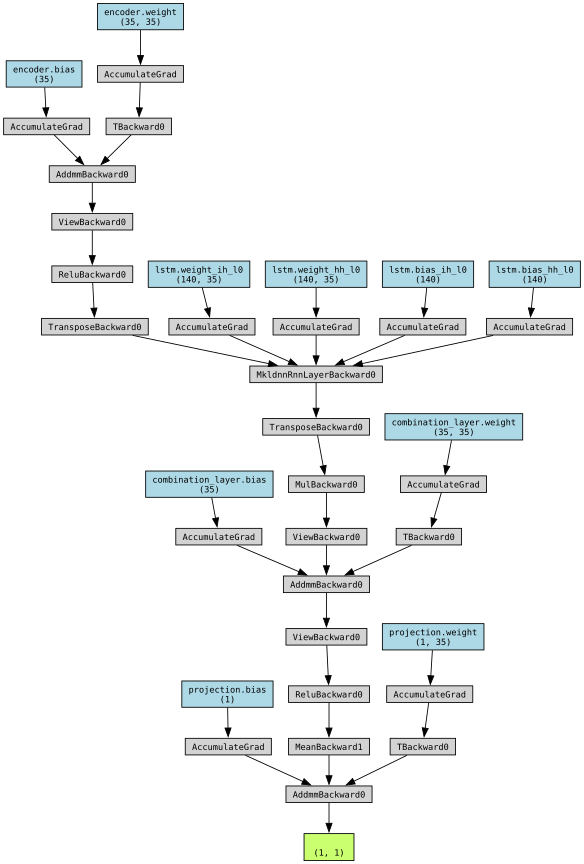

In [37]:
from torchviz import make_dot

# Define the classification model.
model_t = LSTMClassifier(
    tag_size=1,  # binary
    feat_size=35,
    hidden_size=args_test["dim"],
    emb_size=args_test['emb_size'],
    bidirectional=args_test["bidirectional"],
    dropout=args_test['dropout'],
    aggregation_type=args_test['aggregation_type'],
)
# load trained model from file
model_t.load_state_dict(torch.load(args_test['best_model']))
LOGGER.info(model_t)
# model_t = model_t.to(device)
# Create a dummy input tensor with the same shape as your model's input
dummy_input = torch.randn(1, 48, 35)  # (batch_size, sequence_length, feature_size)

# Move the dummy input to the appropriate device
dummy_input = dummy_input.to(next(model_t.parameters()).device)

# Perform a forward pass to get the model's output
output = model_t(dummy_input)

# Create a visualization of the model
dot = make_dot(output, params=dict(model_t.named_parameters()))

# Save the visualization to a file
dot.format = 'png'
dot.render('model_t_diagram')

# Display the diagram
dot

In [27]:
metrics_dict

{'train': [{'acc': 0.7413793,
   'prec0': 0.730198,
   'prec1': 0.74283415,
   'rec0': 0.26977596,
   'rec1': 0.95487475,
   'auroc': 0.8112792164837724,
   'auprc': 0.9049040850455186,
   'epoch': 0},
  {'acc': 0.7402394,
   'prec0': 0.55814695,
   'prec1': 0.8868313,
   'rec0': 0.79881114,
   'rec1': 0.71372384,
   'auroc': 0.8332783898229286,
   'auprc': 0.9169942402196101,
   'epoch': 1},
  {'acc': 0.7966657,
   'prec0': 0.64890283,
   'prec1': 0.88110167,
   'rec0': 0.7572017,
   'rec1': 0.81453115,
   'auroc': 0.8766242763996469,
   'auprc': 0.9427940705804712,
   'epoch': 2},
  {'acc': 0.80877745,
   'prec0': 0.6621881,
   'prec1': 0.8953093,
   'rec0': 0.7887517,
   'rec1': 0.8178431,
   'auroc': 0.8863816948856725,
   'auprc': 0.9475907279449072,
   'epoch': 3},
  {'acc': 0.81191224,
   'prec0': 0.64902025,
   'prec1': 0.9272329,
   'rec0': 0.86328304,
   'rec1': 0.7886566,
   'auroc': 0.9013426565987063,
   'auprc': 0.9558568355583567,
   'epoch': 4},
  {'acc': 0.81048733,
  

## Testing

In [43]:
# Run test on saved model best_classifier
# remember to use the same hyperparameters as in training
args = {
    "best_model": str((Path(model_save_dir) / args_detail).with_suffix(".pth")),
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "data": data_dir,  # path to data
    "notes": data_dir,  # the code ignores the text
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}
print("Result of best_classifier")
metrics_results, pred_probs, y_true = test(args)
metrics_dict["test_best"] = metrics_results

Result of best_classifier
InHospitalMortalityReader init completed
Number of examples:6368
Reading chunk of size 6368
Number of records with more than 48 hours: 56
FEAT_size: 35


[2025-03-01 16:07:14,784 - 636821930.py:43 - test() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)
[2025-03-01 16:07:16,373 - 1116186297.py:8 - print_metrics_binary() - INFO confusion matrix:
[2025-03-01 16:07:16,373 - 1116186297.py:9 - print_metrics_binary() - INFO [[1774  210]
 [ 532 3852]]
[2025-03-01 16:07:16,384 - 1116186297.py:24 - print_metrics_binary() - INFO accuracy = 0.883
[2025-03-01 16:07:16,384 - 1116186297.py:25 - print_metrics_binary() - INFO precision class 0 = 0.769
[2025-03-01 16:07:16,387 - 1116186297.py:26 - print_metrics_binary() - INFO precision class 1 = 0.948
[2025-03-01 16:07:16,389 - 1116186297.py:27 - print_metrics_binary() - INFO recall class 0 = 0.894
[2025-03-01 16:07:16,

In [46]:
metrics_dict["test_best"] 

{'acc': 0.8834799,
 'prec0': 0.7692975,
 'prec1': 0.9483013,
 'rec0': 0.89415324,
 'rec1': 0.87864965,
 'auroc': 0.9481911404373675,
 'auprc': 0.9791154725962701}

# Plot

In [47]:
# Figures ROC and calibration curve
import matplotlib.pyplot as plt
import sys
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms
import pickle
from sklearn import metrics
import pandas as pd

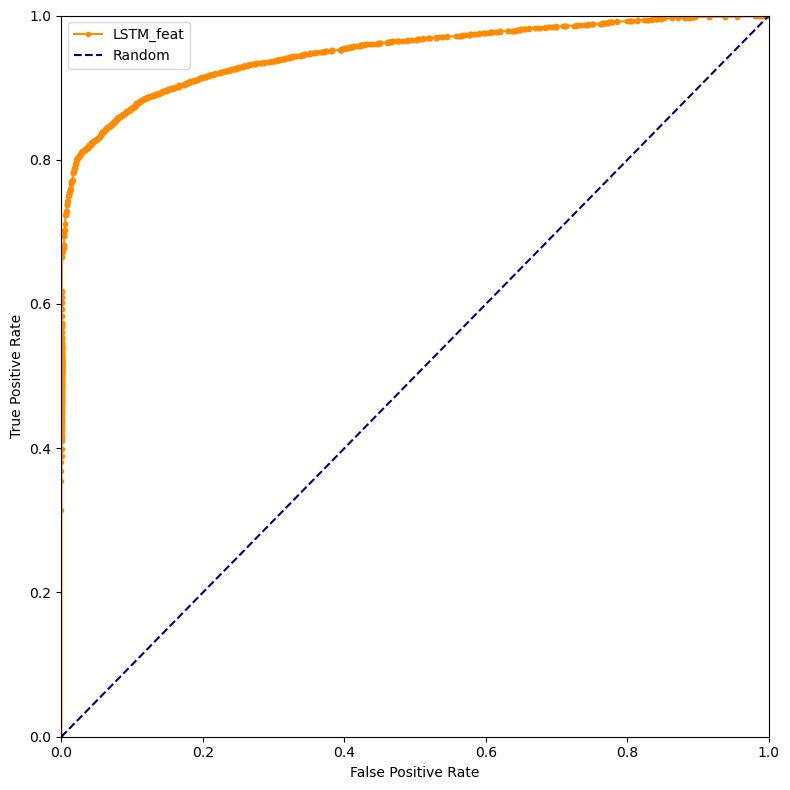

In [48]:
# roc curve
lstm_fpr, lstm_tpr, lstm_thresholds = metrics.roc_curve(y_true, pred_probs)

# plot the roc curve for the model
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.0, 1.0)
ax.plot(lstm_fpr, lstm_tpr, marker=".", label="LSTM_feat", color="darkorange")
ax.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
figure_dict["matplotlib"]["roc_curve"] = fig
fig.tight_layout()

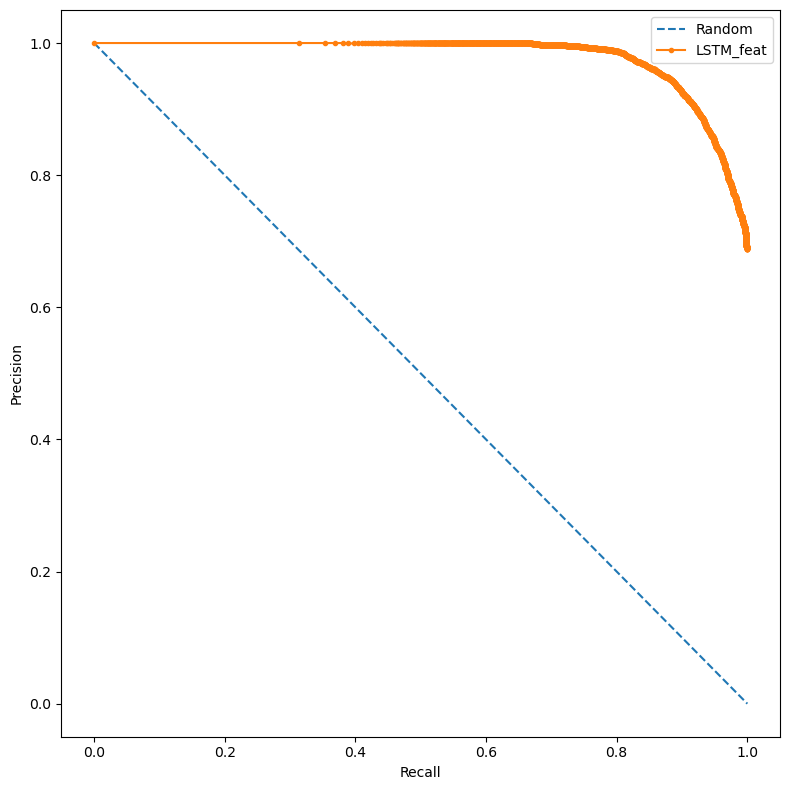

In [49]:
# pr curve
lstm_precision, lstm_recall, _ = metrics.precision_recall_curve(y_true, pred_probs)

# plot the precision-recall curves
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot([0, 1], [1, 0], linestyle="--", label="Random")
ax.plot(lstm_recall, lstm_precision, marker=".", label="LSTM_feat")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
figure_dict["matplotlib"]["pr_curve"] = fig
fig.tight_layout()

FigureCanvasAgg is non-interactive, and thus cannot be shown


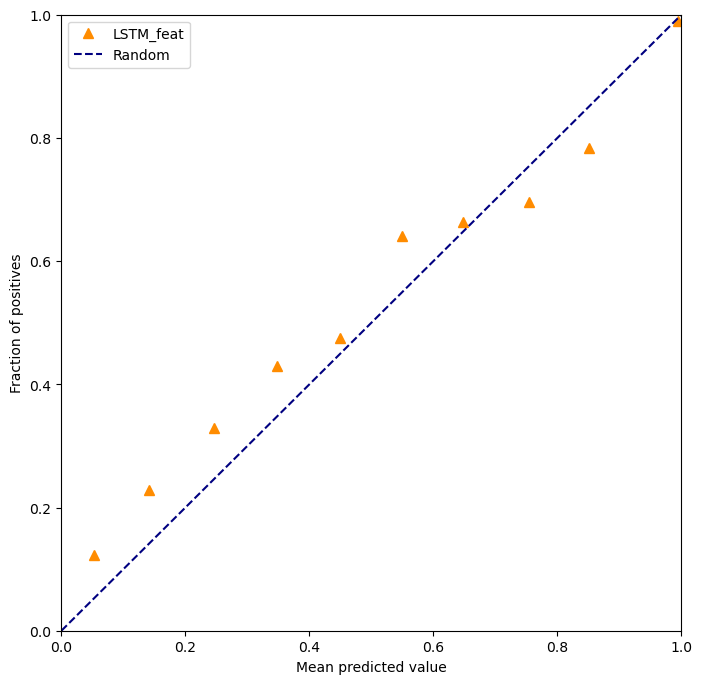

In [50]:
# calibration curve
lstm_y, lstm_x = calibration_curve(y_true, pred_probs, n_bins=10)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.0, 1.0)
ax.plot(lstm_x, lstm_y, marker="^", linestyle="", markersize=7, label="LSTM_feat", color="darkorange")

ax.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random")

ax.set_xlabel("Mean predicted value")
ax.set_ylabel("Fraction of positives")
ax.legend()
figure_dict["matplotlib"]["calibration_curve"] = fig
fig.show()

# Explainability

## SHAP

In [21]:
model_path = 'data/models/2024-12-13/fts_extract_race_groups/_dropout_0.2,batch_size_64,lr_0.pth'

args = {
    "best_model": model_path,
    "dim": 35,
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 35,
    "aggregation_type": "mean",
    "bidirectional": False,
    "data": data_dir,  # path to data
    "notes": data_dir,  # the code ignores the text
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}

In [22]:
# Explain
# Define trainning and validation datasets
mode = "test"
hidden_size = args["dim"]
dropout = args["dropout"]
batch_size = args["batch_size"]
emb_size = args["emb_size"]
best_model = args["best_model"]
data = args["data"]
notes = args["notes"]
timestep = args["timestep"]
aggregation_type = args["aggregation_type"]
bidirectional_encoder = args["bidirectional"]
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
# 1. Get a unique working directory
train_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(data, "train"),
    notes_dir=notes,
    listfile=os.path.join(notes, "train_listfile.csv"),
    period_length=48.0,
)

## Read data
train_dataset = MIMICDataset(train_reader, batch_labels=True)
train_dl = DataLoader(train_dataset, batch_size=100, shuffle=False)

In [23]:
test_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(data, "test"),
    notes_dir=notes,
    listfile=os.path.join(notes, "test_listfile.csv"),
    period_length=48.0,
)

test_dataset = MIMICDataset(test_reader, batch_labels=True)
test_dl = DataLoader(test_dataset, batch_size=100, shuffle=False)
# [B, M, feat_size]
feat_size = test_dataset.data.shape[-1]

InHospitalMortalityReader init completed
Number of examples:6368
Reading chunk of size 6368
Number of records with more than 48 hours: 56


In [24]:
# train_reader._period_length

test_dataset.data.shape
# train_dataset.data.shape
# train_dataset.T
# train_dataset.y

(6368, 96, 35)

In [25]:
best_model

'data/models/2024-12-13/fts_extract_race_groups/_dropout_0.2,batch_size_64,lr_0.pth'

In [26]:
# Define the classification model.
model = LSTMClassifier(
    tag_size=1,  # binary
    feat_size=feat_size,
    hidden_size=hidden_size,
    emb_size=emb_size,
    bidirectional=bidirectional_encoder,
    dropout=dropout,
    aggregation_type=aggregation_type,
)

# load trained model from file
model.load_state_dict(torch.load(best_model))
LOGGER.info(model)
model = model.to(device)

[2025-02-02 21:10:33,020 - 2217917587.py:14 - <module>() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


In [28]:
batch = next(iter(test_dl))
print(f'Size of the batch: {len(batch[0])}')

data, labels = batch
data = data.to(device)
background = data[:100]

test_data = data[:10]
labels_test = labels[:10]

Size of the batch: 100


In [29]:
test_data

tensor([[[0.4667, 0.2105, 0.3462,  ..., 0.0000, 0.0000, 0.0000],
         [1.1333, 0.2105, 0.3462,  ..., 0.0000, 0.0000, 0.0000],
         [2.1333, 0.2105, 0.3462,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.5842, 0.3684, 0.1923,  ..., 0.0000, 0.0000, 0.0000],
         [1.5842, 0.3684, 0.3462,  ..., 0.0000, 0.0000, 0.0000],
         [2.5842, 0.3684, 0.3462,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.5667, 0.4211, 0.5000,  ..., 0.0000, 0.0000, 0.0000],
         [1.5667, 0.4211, 0.5000,  ..., 0.0000, 0.0000, 0.0000],
         [2.5667, 0.4211, 0.5000,  ..., 0.0000, 0.0000, 0.

In [30]:
print("Background data shape:", background.shape)
print("Test data shape:", test_data.shape)

Background data shape: torch.Size([100, 96, 35])
Test data shape: torch.Size([10, 96, 35])


### LMST Interpreter

In [44]:
import shap
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        return self.model(x)

class LSTMInterpreter:
    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model
        self.device = device
        self.model.to(device)
        self.model.eval()
        # self.model.train()
        # model.train()
        self.wrapper = ModelWrapper(self.model)
        
    def prepare_background(self, background_data, batch_size=32):
        """Prepare background dataset for SHAP."""
        # Convert numpy to torch tensor if needed
        if isinstance(background_data, np.ndarray):
            background_data = torch.FloatTensor(background_data)
            
        return background_data.to(self.device)
    
    def predict_fn(self, inputs):
        """
        Prediction function for SHAP to use
        
        Args:
            inputs: numpy array of shape (n_samples, sequence_length, n_features)
        
        Returns:
            numpy array of predictions
        """
        with torch.no_grad():
            # Convert numpy to torch
            torch_inputs = torch.FloatTensor(inputs).to(self.device)
            
            # Get model predictions
            outputs = self.model(torch_inputs)
            
            # Convert back to numpy
            return outputs.cpu().numpy()
    
    def explain_instance(self, instance, background_data, n_samples=100):
        """
        Explain a single instance using DeepSHAP.
        
        Args:
            instance: numpy array of shape (length, n_features)
            background_data: numpy array of shape (n_background, length, n_features)
            n_samples: number of samples for SHAP calculation
        """
        # Ensure instance is 3D (batch_size=1, length, n_features)
        if len(instance.shape) == 2:
            instance = np.expand_dims(instance, 0)

        self.wrapper.model.train()
            
        # Convert to torch tensors
        instance_tensor = torch.FloatTensor(instance).to(self.device)
        
        # Prepare background data
        background = self.prepare_background(background_data)
        
        # Create DeepExplainer with the wrapper
        try:
            explainer = shap.DeepExplainer(
                self.wrapper,
                background
            )
            
            # Get SHAP values
            shap_values = explainer.shap_values(instance_tensor)
            
            # Convert to numpy and reshape
            if isinstance(shap_values, list):
                shap_values = shap_values[0]  # For binary classification
            
            feature_importance = shap_values[0]  # Remove batch dimension
            time_importance = np.abs(feature_importance).mean(axis=1)

            self.wrapper.model.eval()
            
            return feature_importance, time_importance
            
        except Exception as e:
            print(f"Error in explain_instance: {str(e)}")
            print(f"Background shape: {background.shape}")
            print(f"Instance shape: {instance_tensor.shape}")
            self.wrapper.model.eval()
            raise e
    
    def explain_batch(self, instances, background_data, batch_size=32):
        """
        Explain multiple instances using DeepSHAP.
        
        Args:
            instances: numpy array of shape (n_instances, length, n_features)
            background_data: numpy array of shape (n_background, length, n_features)
            batch_size: size of batches for processing
        """
        if isinstance(instances, np.ndarray):
            instances = torch.FloatTensor(instances)
            
        loader = DataLoader(
            TensorDataset(instances),
            batch_size=batch_size,
            shuffle=False
        )
        
        background = self.prepare_background(background_data)
        explainer = shap.DeepExplainer(
            self.wrapper,
            background
        )
        
        all_explanations = []
        
        with torch.no_grad():
            for batch in loader:
                batch = batch[0].to(self.device)
                shap_values = explainer.shap_values(batch)
                
                if isinstance(shap_values, list):
                    shap_values = shap_values[0]
                
                # Process each instance in the batch
                for instance_shap in shap_values:
                    feature_importance = instance_shap
                    time_importance = np.abs(feature_importance).mean(axis=1)
                    all_explanations.append((feature_importance, time_importance))
                
        return all_explanations

def plot_feature_importance(feature_importance, feature_names=None, time_steps=None):
    """
    Plot feature importance heatmap
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(feature_importance, 
                xticklabels=feature_names if feature_names else 'auto',
                yticklabels=time_steps if time_steps else 'auto',
                cmap='RdBu', center=0)
    plt.xlabel('Features')
    plt.ylabel('Time steps')
    plt.title('Feature Importance Over Time')
    plt.show()
    
    # Plot time importance
    time_importance = np.abs(feature_importance).mean(axis=1)
    plt.figure(figsize=(12, 4))
    plt.plot(time_importance)
    plt.xlabel('Time steps')
    plt.ylabel('Average |SHAP value|')
    plt.title('Time Step Importance')
    plt.show()

In [45]:
interpreter = LSTMInterpreter(model)

In [46]:
background_numpy = background.cpu().numpy()
test_data_numpy = test_data.cpu().numpy()

print("Background data shape:", background_numpy.shape)
print("Test data shape:", test_data_numpy.shape)

Background data shape: (100, 96, 35)
Test data shape: (10, 96, 35)


In [47]:
feature_importance, time_importance = interpreter.explain_instance(
    test_data_numpy[0],
    background_numpy
)

Error in explain_instance: cudnn RNN backward can only be called in training mode
Background shape: torch.Size([100, 96, 35])
Instance shape: torch.Size([1, 96, 35])


RuntimeError: cudnn RNN backward can only be called in training mode

### DeepExplainer

In [50]:
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(test_data)

RuntimeError: cudnn RNN backward can only be called in training mode

In [51]:
# explainer = shap.Explainer(model, background_numpy)
# shap_values = explainer(test_data_numpy)

Error presented when running the next cell:

* `RuntimeError: cudnn RNN backward can only be called in training mode:` SHAP needs the model to be in training mode for proper gradient computation during the attribution process.

In [159]:
# test_data_flattened = test_data[0].unsqueeze(0)

In [169]:
# shap_values = explainer.shap_values(test_data[0].unsqueeze(0))

shap_values = explainer.shap_values(test_data)

c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 26.945740406890764 - Tolerance: 0.01

Solutions:
1. Set the Model to Training Mode. model.train() before and model.eval() after it.

In [52]:
model.train()
shap_values = explainer.shap_values(test_data)
model.eval()

c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 27.06898203111996 - Tolerance: 0.01

The Above cell cause the next one:
* `AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 21.42269716959757 - Tolerance: 0.01`

In [53]:
# check_additivity = False - To allow minor discrepancies in the sum
shap_values = explainer.shap_values(test_data, check_additivity=False)

In [55]:
# init the JS visualization code
shap.initjs()

In [56]:
print(f' Shape of test data: {test_data.shape}')
print(f' Shape of shap values: {shap_values.shape}')

shap_values_squeezed = shap_values.squeeze(-1)
print(f' Shape of shap values squeezed: {shap_values_squeezed.shape}')

 Shape of test data: torch.Size([10, 96, 35])
 Shape of shap values: (10, 96, 35, 1)
 Shape of shap values squeezed: (10, 96, 35)


#### Summary plot

In [57]:
shap_values_squeezed.shape

(10, 96, 35)

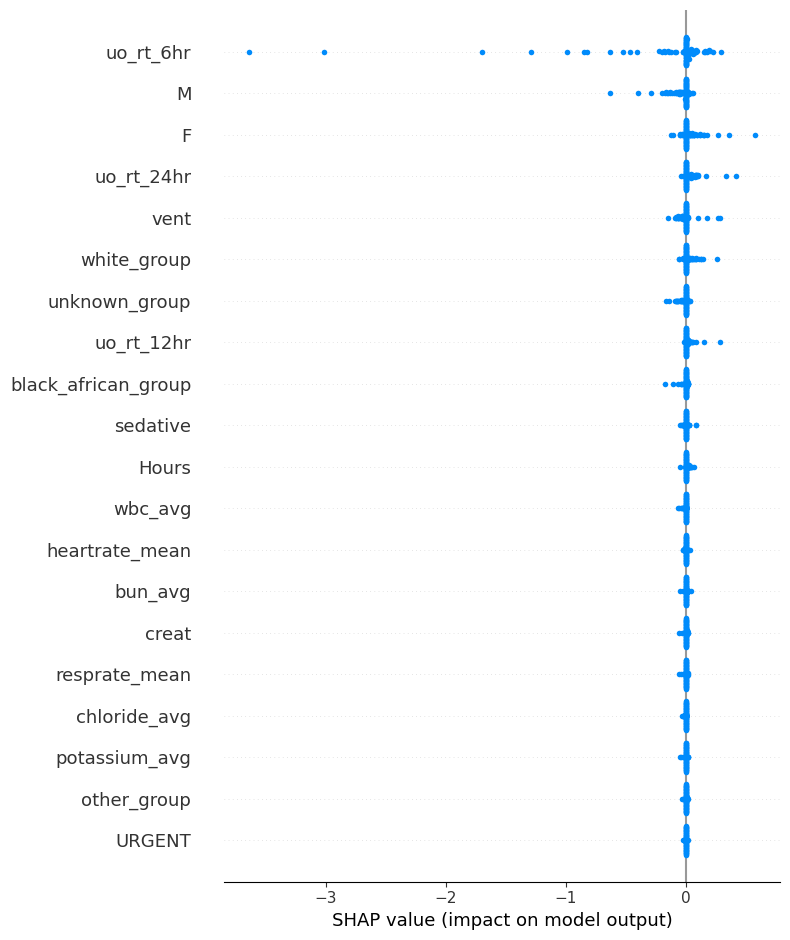

In [59]:
# Plot the summary plot
shap.summary_plot(shap_values_squeezed[5], feature_names=test_dataset.features)

#### Heatmap

In [210]:
shap_values_squeezed.shape

(10, 96, 35)

In [217]:
shap_values.shape

(10, 96, 35, 1)

In [228]:
# import shap
# import torch

# # Ensure model is in evaluation mode
# model.eval()

# # Disable cuDNN for RNN if necessary
# torch.backends.cudnn.enabled = False

# # Explaining predictions using SHAP DeepExplainer without additivity check
# explainer = shap.DeepExplainer(model, background)
# shap_values = explainer.shap_values(test_data, check_additivity=False)

# # If shap_values is a list, extract the first element (assuming it's the relevant output)
# shap_values = shap_values[0]  # Adjust this if needed for multi-output models

# # Squeeze the SHAP values if necessary
# shap_values_squeezed = shap_values.squeeze(-1)  # Assuming you want to remove singleton dimensions

# print(f"Shape of shap_values_squeezed: {shap_values_squeezed.shape}")
# print(f"Shape of test data: {test_data[0].shape}")


# Wrap the SHAP values in a shap.Explanation object for plotting
shap_values_explanation = shap.Explanation(values=shap_values_squeezed, 
                                           data=test_data, 
                                        #    feature_names=[f"Feature {i}" for i in range(shap_values_squeezed.shape[1])]
                                           feature_names=train_dataset.features)

#### Heatmap

In [147]:
shap_values_squeezed.shape

(10, 96, 35)

In [ ]:
# import shap
# import torch

# # Ensure model is in evaluation mode
# model.eval()

# # Disable cuDNN for RNN if necessary
# torch.backends.cudnn.enabled = False

# # Explaining predictions using SHAP DeepExplainer without additivity check
# explainer = shap.DeepExplainer(model, background)
# shap_values = explainer.shap_values(test_data, check_additivity=False)

# # If shap_values is a list, extract the first element (assuming it's the relevant output)
# shap_values = shap_values[0]  # Adjust this if needed for multi-output models

# # Squeeze the SHAP values if necessary
# shap_values_squeezed = shap_values.squeeze(-1)  # Assuming you want to remove singleton dimensions

# print(f"Shape of shap_values_squeezed: {shap_values_squeezed.shape}")
# print(f"Shape of test data: {test_data[0].shape}")


# Wrap the SHAP values in a shap.Explanation object for plotting
shap_values_explanation = shap.Explanation(values=shap_values_squeezed, 
                                           data=test_data[0], 
                                        #    feature_names=[f"Feature {i}" for i in range(shap_values_squeezed.shape[1])]
                                           feature_names=train_dataset.features)

In [ ]:
shap_values_explanation[0].shape
# Plot the heatmap of the SHAP values
# shap.plots.heatmap(shap_values_squeezed)

In [193]:
# Plot the summary plot
shap.plots.heatmap(shap_values_explanation[0])

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (96, 35)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

### GradientExplainer

#### waterfall 

In [26]:
import shap

# Select a specific instance (e.g., instance 0)
instance_idx = 0
instance_data = test_data[instance_idx]

# Extract SHAP values for the selected instance
shap_values_instance = shap_values_squeezed[instance_idx]

# Wrap the SHAP values in a shap.Explanation object for the specific instance
shap_values_explanation_instance = shap.Explanation(values=shap_values_instance, 
                                                    data=instance_data, 
                                                    # feature_names=[f"Feature {i}" for i in range(shap_values_instance.shape[0])]
                                                    feature_names=train_dataset.features)


In [33]:

# Plot the waterfall plot for the selected instance
shap.plots.waterfall(shap_values_explanation[0])

In [82]:
try:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    shap_values = e.shap_values(test_data)
    shap.summary_plot(shap_values, test_data, feature_names=test_dataset.features, show=False, ax=ax)
    fig.tight_layout()
except:
    LOGGER.exception("Error computing SHAP")

torch.Size([16, 96, 35])

In [83]:
num_batches = len(test_dl)
print(f'The number of batches in test_dl is: {num_batches}')

The number of batches in test_dl is: 398


In [ ]:
# Extract a single instance from the batch
single_instance, single_label = single_batch[0][0], single_batch[1][0]

# Print the instance and its label
print(f'Shape of the instance: {single_instance.shape}. Length of the shape: {len(single_instance.shape)}')
print(single_instance)
print(single_label)

In [29]:
feature_names = [
    'Hours','aniongap_avg',
    'bicarbonate_avg','bun_avg','chloride_avg','creat','diasbp_mean','glucose_avg',
    'heartrate_mean','hematocrit_avg','hemoglobin_avg','potassium_avg','resprate_mean',
    'sodium_avg','spo2_mean','sysbp_mean','uo_rt_12hr','uo_rt_24hr','uo_rt_6hr','wbc_avg',
    'sedative','vasopressor','vent','anchor_age','F','M',
    'white_group','black_african_group','asian_group','hispanic_group','unknown_group','native_group',
    'other_group','ELECTIVE','URGENT',
]

In [54]:
def flatten_timeseries( X):
    """
    Flatten time series data
    
    Parameters:
    - X: Time series data (batch of samples)
    
    Returns:
    - Flattened data
    """
    # Handle different input shapes
    if len(X.shape) == 3:
        # (batch_size, time_steps, features)
        return X.reshape(X.shape[0], -1)
    elif len(X.shape) == 4:
        # (batch_size, channels, time_steps, features)
        return X.reshape(X.shape[0], -1)
    return X

In [66]:
# Prepare the data for LIME
reference_data = []
reference_labels = []

count = 0;

# Iterate through data loader to collect reference samples
for batch_idx, (inputs, labels) in enumerate(train_dl):
    # Convert to numpy if using PyTorch tensors
    if torch.is_tensor(inputs):
        inputs = inputs.numpy()
    if torch.is_tensor(labels):
        labels = labels.numpy()
    
    if(count < 10):
        print('inputs:', inputs.shape)
        count += 1

    # Flatten the inputs
    flattened_inputs = flatten_timeseries(inputs)
    # flattened_inputs = inputs
    
    reference_data.extend(flattened_inputs)
    reference_labels.extend(labels)
    
    # Stop after collecting desired number of samples
    # if len(reference_data) >= num_samples:
    #     break

reference_dataset = np.array(reference_data)
print('Length of reference dataset:', len(reference_dataset))

inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
Length of reference dataset: 51996


In [63]:
# Current function use to train a model
# metrics_results, pred_probs, y_true = eval_model(model, test_dl, device)

(51996, 5040)

In [72]:
# Get a single batch from the test data loader
single_batch = next(iter(test_dl))
single_batch[0].shape

array([0.46666667, 0.6315789 , 0.42307693, ..., 0.        , 0.        ,
       0.        ], dtype=float32)

In [62]:
num_batches = len(test_dl)
print(f'The number of batches in test_dl is: {num_batches}')

['feature_0',
 'feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'feature_13',
 'feature_14',
 'feature_15',
 'feature_16',
 'feature_17',
 'feature_18',
 'feature_19',
 'feature_20',
 'feature_21',
 'feature_22',
 'feature_23',
 'feature_24',
 'feature_25',
 'feature_26',
 'feature_27',
 'feature_28',
 'feature_29',
 'feature_30',
 'feature_31',
 'feature_32',
 'feature_33',
 'feature_34',
 'feature_35',
 'feature_36',
 'feature_37',
 'feature_38',
 'feature_39',
 'feature_40',
 'feature_41',
 'feature_42',
 'feature_43',
 'feature_44',
 'feature_45',
 'feature_46',
 'feature_47',
 'feature_48',
 'feature_49',
 'feature_50',
 'feature_51',
 'feature_52',
 'feature_53',
 'feature_54',
 'feature_55',
 'feature_56',
 'feature_57',
 'feature_58',
 'feature_59',
 'feature_60',
 'feature_61',
 'feature_62',
 'feature_63',
 'feature_64',
 'feature_65',
 'feature_66',
 'fea

In [73]:
# Extract a single instance from the batch
single_instance, single_label = single_batch[0][0], single_batch[1][0]

# Print the instance and its label
print(f'Shape of the instance: {single_instance.shape}. Length of the shape: {len(single_instance.shape)}')
print(single_instance)
print(single_label)

In [9]:
feature_names = [
    'Hours','aniongap_avg',
    'bicarbonate_avg','bun_avg','chloride_avg','creat','diasbp_mean','glucose_avg',
    'heartrate_mean','hematocrit_avg','hemoglobin_avg','potassium_avg','resprate_mean',
    'sodium_avg','spo2_mean','sysbp_mean','uo_rt_12hr','uo_rt_24hr','uo_rt_6hr','wbc_avg',
    'sedative','vasopressor','vent','anchor_age','F','M',
    'white_group','black_african_group','asian_group','hispanic_group','unknown_group','native_group',
    'other_group','ELECTIVE','URGENT',
]

In [76]:
# Explain the instance
explanation = explainer.explain_instance(
    X_test_reshaped,  # First instance if batch
    eval_model, 
    num_features=len(feature_names_2),
    # top_labels=1
)

IndexError: index 35 is out of bounds for axis 1 with size 35

In [ ]:
# Define the prediction function
def predict_function(x):
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(x, dtype=torch.float32).reshape(x.shape[0], -1, feat_size).to(device)
        logits = model(x_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

# Choose a sample to explain
explanation = explainer.explain_instance(
    X_test_reshaped[0],  # Single flattened instance
    predict_function,    # The model's prediction function
    num_features=35  # Number of features to visualize
)

explanation.show_in_notebook()

## LIME

In [8]:
from lime import lime_tabular

In [ ]:
explainer = lime_tabular.RecurrentTabularExplainer(
    X, training_labels = y,
    feature_names = feature_names,
    discretize_continuous = True,
    class_names = ['no_aki','with_aki'],
    discretizer = 'decile')

# Saving Results

In [ ]:
# Saving stuff
(Path(results_save_dir) / "figures").mkdir(parents=True, exist_ok=True)
for key in figure_dict["matplotlib"]:
    figure_dict["matplotlib"][key].savefig(f"{results_save_dir}/figures/{key}.png")
with open(f"{results_save_dir}/metrics.json", "w") as f:
    json.dump(dict_to_str(deepcopy(metrics_dict)), f, indent=4, sort_keys=True)